In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
# AAPL.csv 로드 -> 인덱스 지정
df = pd.read_csv("./../csv/AAPL.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.410525,117258400.0
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.389106,43971200.0
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.360548,26432000.0
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.369472,21610400.0
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.380182,18362400.0


In [22]:
# 인덱스를 지정하는 함수 set_index()
df.set_index('Date')[['Adj Close']]

,Adj Close
Date,
1980-12-12,0.410525
1980-12-15,0.389106
1980-12-16,0.360548
1980-12-17,0.369472
1980-12-18,0.380182
...,...
2019-06-18,198.449997
2019-06-19,197.869995
2019-06-20,199.460007


In [20]:
df2 = pd.read_csv("./../csv/AAPL.csv",index_col="Date", usecols=['Adj Close','Date'])

In [23]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9715 entries, 1980-12-12 to 2019-06-24
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  9714 non-null   float64
dtypes: float64(1)
memory usage: 151.8+ KB


In [35]:
df2['Adj Close'].isna()

Date
1980-12-12    False
1980-12-15    False
1980-12-16    False
1980-12-17    False
1980-12-18    False
              ...  
2019-06-18    False
2019-06-19    False
2019-06-20    False
2019-06-21    False
2019-06-24    False
Name: Adj Close, Length: 9715, dtype: bool

In [39]:
index_list = df2.loc[df2['Adj Close'].isna(),].index

In [40]:
index_list

Index(['1981-08-10'], dtype='object', name='Date')

In [37]:
from datetime import datetime

In [48]:
for idx in index_list:
    # print(type(idx))
    time_idx = datetime.strptime(idx, '%Y-%m-%d')
    # print(time_idx)
    # 시계열 데이터에서 요일을 추출하여 문자로 출력
    print(time_idx.strftime('%A'))

Monday


In [50]:
# 결측치를 제외한다
df2.dropna(axis=0, inplace=True)

In [ ]:
# 이동평균선 -> 오늘에서부터 과거의 n개의 데이터를 
# 모아서 평균을 낸 데이터
# 20일 평균선 -> 첫데이터에서 20일 후부터 생성이 되는 데이터
# 20번째 데이터에서 첫 이동평균선 데이터가 생성
df2.iloc[ 0:20, 0].mean() # df2.iloc[ 19, 1] 대입
df2.iloc[ 1:21, 0].mean() # df2.iloc[ 20, 1] 대입
# df2.iloc[i+19, 1] = df2.iloc[i : i+20, 0].mean()

np.float64(0.4432777)

In [57]:
import numpy as np

In [58]:
df2['center'] = np.nan

In [60]:
for i in range(len(df2)-19):
    df2.iloc[i+19,1] = df2.iloc[i:i+20,0].mean()

In [63]:
df2.iloc[18:22]

,Adj Close,center
Date,,
1981-01-09,0.455147,NaN
1981-01-12,0.451577,0.443278
1981-01-13,0.435513,0.444527
1981-01-14,0.437298,0.446937


In [64]:
df2['while_center'] = np.nan

In [65]:
i = 0
while True:
    try:
        df2.iloc[i+19,2] = df2.iloc[i:i+20,0].mean()
        i += 1
    except:
        break
    

In [67]:
df2.tail()

,Adj Close,center,while_center
Date,,,
2019-06-18,198.449997,185.4325,185.4325
2019-06-19,197.869995,185.9960,185.9960
2019-06-20,199.460007,186.8300,186.8300
2019-06-21,198.779999,187.7860,187.7860
2019-06-24,199.169998,188.7960,188.7960


In [70]:
# 데이터를 n개 만큼 묶어서 그룹화 함수
# rolling(n)
df2['center2'] = df2['Adj Close'].rolling(20).mean()

In [71]:
df2.tail()

,Adj Close,center,while_center,center2
Date,,,,
2019-06-18,198.449997,185.4325,185.4325,185.4325
2019-06-19,197.869995,185.9960,185.9960,185.9960
2019-06-20,199.460007,186.8300,186.8300,186.8300
2019-06-21,198.779999,187.7860,187.7860,187.7860
2019-06-24,199.169998,188.7960,188.7960,188.7960


In [73]:
# 인덱스를 시계열 반환
df2.index = pd.to_datetime(df2.index)

In [75]:
df2 = df2.tail(100)

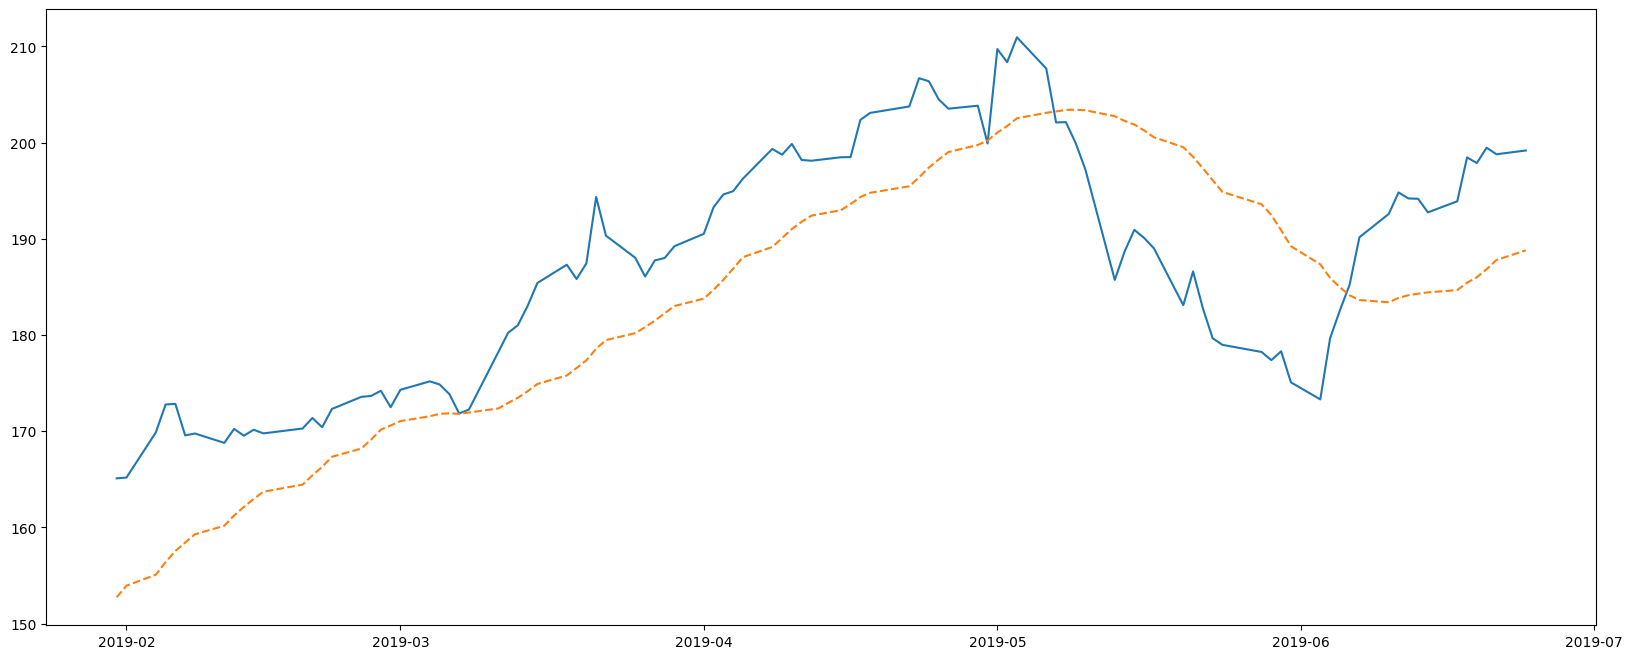

In [76]:
plt.figure(figsize=(20,8))

plt.plot(df2.index, df2['Adj Close'])
plt.plot(df2.index, df2['center'],'--')

plt.show()